# Delphes event analysis

Example analysis based on ILC generic detector model (delphes_card_ILCgen.tcl)

For description of the data structure see: https://github.com/iLCSoft/ILCDelphes/blob/master/doc/Data.md 

For description of Delphes objects, have a look at the header file: /opt/Delphes-3.5.0/classes/DelphesClasses.h

## Setup the environment

In [1]:
#General utility libraries
import os, sys, subprocess, time

#General data operations library
import math
import numpy as np

# Scientific Python tools
from scipy.optimize import curve_fit

# For reading Delphes output
import ROOT

#Plotting libraries
import matplotlib.pyplot as plt

#Increase plots font size
params = {'legend.fontsize': 'xx-large',
          'figure.figsize': (10, 7),
         'axes.labelsize': 'xx-large',
         'axes.titlesize':'xx-large',
         'xtick.labelsize':'xx-large',
         'ytick.labelsize':'xx-large'}
plt.rcParams.update(params)

## Load Delphes environment

In [2]:
# Load delphes libraries 

ROOT.gInterpreter.AddIncludePath('/opt/Delphes-3.5.0/')
ROOT.gInterpreter.AddIncludePath('/opt/Delphes-3.5.0/external')
ROOT.gInterpreter.Declare('#include "classes/DelphesClasses.h"')
ROOT.gInterpreter.Declare('#include "external/ExRootAnalysis/ExRootTreeReader.h"')

ROOT.gSystem.Load("/opt/Delphes-3.5.0/libDelphes")

0

## Process input file

In [3]:
# Process to be studied
proc = "Zmumu"
inputFile = proc + "_delphes.root"

# Create chain of root trees and add selected input file
chain = ROOT.TChain("Delphes")
chain.Add(inputFile)

# Create object of class ExRootTreeReader
treeReader = ROOT.ExRootTreeReader(chain)
numberOfEntries = treeReader.GetEntries()

print("Input chain opened with {} entries".format(numberOfEntries))

Input chain opened with 10000 entries


In [4]:
# Get pointers to branches used in the analysis

# Pythia level information (not available in the real experiment!!!)

branchParticle = treeReader.UseBranch("Particle")

# Final state reconstructed objects

branchPhoton = treeReader.UseBranch("Photon")
branchElectron = treeReader.UseBranch("Electron")
branchMuon = treeReader.UseBranch("Muon")

# Multiple jet collections available for analysis,
# with fixed jet multiplicities from Durham algorithm ("Jet_N2", "Jet_N3", ... ,"Jet_N6")
# or inclusive clusstering with anti-kt algorithm ("Jet")
 
branchJet = treeReader.UseBranch("Jet")

In [5]:
# Analysis results (number of accepted events not known!)

Mgen = []     # Generated invariant mass (Pythia level)
Msel = []     # Generated invariant mass (Pythia level) for selected events
Mdet = []     # Reconstructed invariant mass  (Delphes level)
Mrec = []     # Recoil mass (invariant mass of what was is left)

In [6]:
# Loop over all events

P4zero = ROOT.TLorentzVector(0,0,0,0)
P4cms = ROOT.TLorentzVector(0,0,0,240)

for entry in range(0, numberOfEntries):
    
    # Load selected branches with data from specified event
    treeReader.ReadEntry(entry)

    # Particles in the final state (generator level)
    nParticle = branchParticle.GetEntries()

    # Reconstructed final state objects
    nPhoton   = branchPhoton.GetEntries()
    nElectron = branchElectron.GetEntries()
    nMuon     = branchMuon.GetEntries()
    nJet      = branchJet.GetEntries()

    # Look for last Z0 (PID==23) in event record

    Zpart = 0
    
    for ipar in range(0,nParticle):
        part = branchParticle.At(ipar)
        if part.PID == 23 : Zpart = part

    # direct Z  decay products in history tree
    
    ZD1 =  branchParticle.At(Zpart.D1) 
    ZD2 =  branchParticle.At(Zpart.D2) 

    # Store generated invariant mass of Z0
    
    P4gen = ZD1.P4() + ZD2.P4()
    
    Mgen.append(P4gen.M())

    # Event selection based on reconstructed object count
    
    # Require two muons
    
    if nMuon != 2  : continue

    # Possible veto on other objects
    
    # if nElectron != 0  : continue
    # if nPhoton != 0  : continue
    # if nJet != 0  : continue

    Msel.append(P4gen.M())
    
    # Two moun analysis
    
    mu1 = branchMuon.At(0)
    mu2 = branchMuon.At(1)

    # Invariant mass of two muons, as measured in the detector
    
    P4det = mu1.P4() + mu2.P4()    # mu pair four-momentum

    Mdet.append(P4det.M())

    # Recoil mass (or missing mass; invariant mass of what is left)

    P4rec = P4cms - P4det

    Mrec.append(P4rec.M())


In [7]:
Mgen = np.array(Mgen)
Msel = np.array(Msel)
Mdet = np.array(Mdet)
Mrec = np.array(Mrec)

print("Total of {} generated pairs, {} reconstructed".format(Mgen.size,Mdet.size))

Total of 10000 generated pairs, 8564 reconstructed


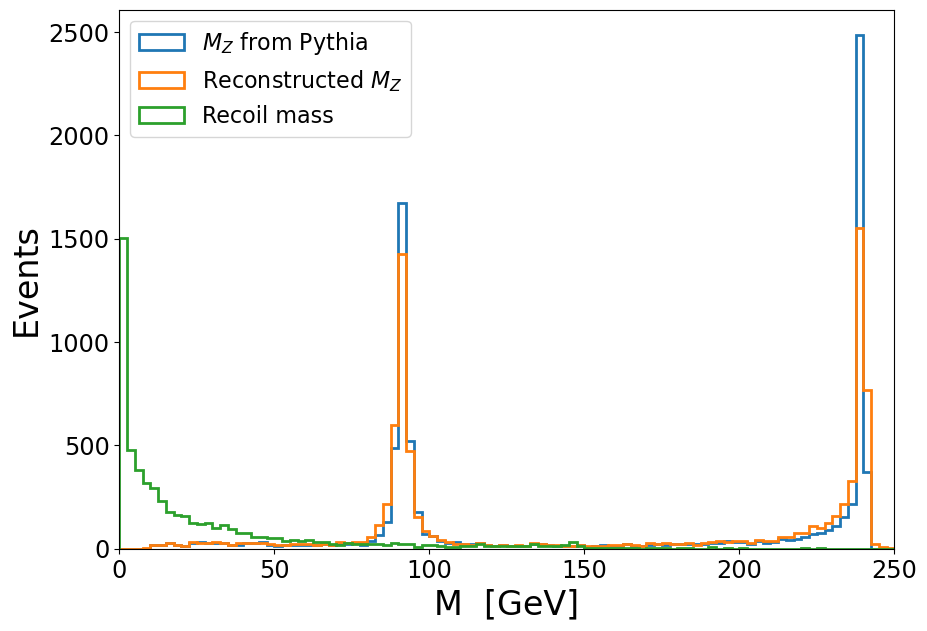

In [8]:
logflag = False
plt.hist(Msel,bins=100,log=logflag,range=[0.,250.], histtype='step',linewidth=2,label='$M_Z$ from Pythia')
plt.hist(Mdet, bins=100,log=logflag,range=[0.,250.], histtype='step',linewidth=2,label='Reconstructed $M_Z$')
plt.hist(Mrec, bins=100,log=logflag,range=[0.,250.], histtype='step',linewidth=2,label='Recoil mass')
plt.xlim(0.,250.)
plt.xlabel('M  [GeV]',size=24)
plt.ylabel('Events',size=24)

plt.legend(loc='upper left',fontsize=16)
plt.show()

### Result discussion

Process defined in PYTHIA is: 
          $$e^+e^- \to Z^{(*)} \to \mu^+\mu^-$$ 
Assuming invariant mass of the colliding $e^+e^-$ pair is $E_{CMS}$= 240 GeV, also the invariant mass of the muon pair should be equal to the collision energy. We do see a 240 GeV peak in the distribution, but there is also another one, around 90 GeV. It is due to so called radiative-return events: 
          $$e^+e^- \to Z  \gamma \to \mu^+\mu^- \gamma \; ,$$ 
where additional photon is emitted from the initial state electron (or positron) to reduce the colision energy to the Z boson mass. In most processes initial state radiation (ISR) gives only small correction to the leading order process (suppressed by factor $\alpha_{em}$), but the cross section for resonant Z production is orders of magnitude higher than for the process with virtual Z exchange, so for the considered process contribution of radiative-return events in the final sample is comparable to that of the non-radiative events.

In [9]:
# Breit Wiggner + flat Bg

def myfun(x,loc,scale,Sig,Bg):
    val = Sig * scale *scale/((x-loc)*(x-loc) + scale*scale/4.) + Bg;     # Gauss
    return val

# Mass distribution fit and plot

def mass_fit(Mfit,Mmin=60.,Mmax=110.,Mbin=50):

    masshist = np.histogram(Mfit, bins=Mbin,range=[Mmin,Mmax],density=False)
    
    yval = masshist[0]
    yerr = np.sqrt(yval+1)
    xval = (masshist[1][1:] + masshist[1][:-1])/2.

    Msel = Mfit[(Mfit>Mmin)*(Mfit<Mmax)]
    Pini = np.array([np.mean(Msel),np.std(Msel),Msel.size,10.])
    
    #  print("\n Initial fit parameter guess: ",Pini)
    
    par, pcov = curve_fit(myfun, xval, yval, p0=Pini, sigma=yerr,absolute_sigma=True)
    epar = np.sqrt(np.diagonal(pcov))
    
    print("\n curve_fit results:\n\n     par         sigma_p\n")
    
    for ip in range(par.size):
        print("  %8.3f  +/- %6.3f " % (par[ip],epar[ip]))
    
    # Calculate correlation matrix
    '''
    Corr = pcov/np.outer(epar,epar)
    
    np.set_printoptions(precision=3)
    
    print("\n Correlation matrix\n")
    
    for ip in range(par.size):
        print(Corr[ip,:])
    '''
    # Fitted function values
    
    fval = myfun(xval,*par) 
    
    # Chi^2 printout
    
    chi2 = np.sum((yval-fval)**2/yerr**2)
    
    print("\n chi^2 =  %8.3f   chi^2/Ndf = %8.5f " % (chi2,chi2/(xval.size-par.size)))
    
    # Finer point grid for drawing
    dx = (Mmax-Mmin)/Mbin/5.
    xfit = np.arange(Mmin,Mmax,dx)
    ffit = myfun(xfit,*par) 
    
    logflag = False
    plt.hist(Mfit, bins=Mbin,log=logflag,range=[Mmin,Mmax], histtype='step',linewidth=2)
    plt.plot(xfit,ffit,'r--')
    plt.xlim(Mmin,Mmax)
    plt.xlabel('M  [GeV]',size=24)
    plt.ylabel('Events',size=24)
    
    plt.show()


 curve_fit results:

     par         sigma_p

    91.282  +/-  0.030 
     2.598  +/-  0.070 
   235.282  +/-  6.697 
     5.244  +/-  0.671 

 chi^2 =    61.812   chi^2/Ndf =  1.34375 


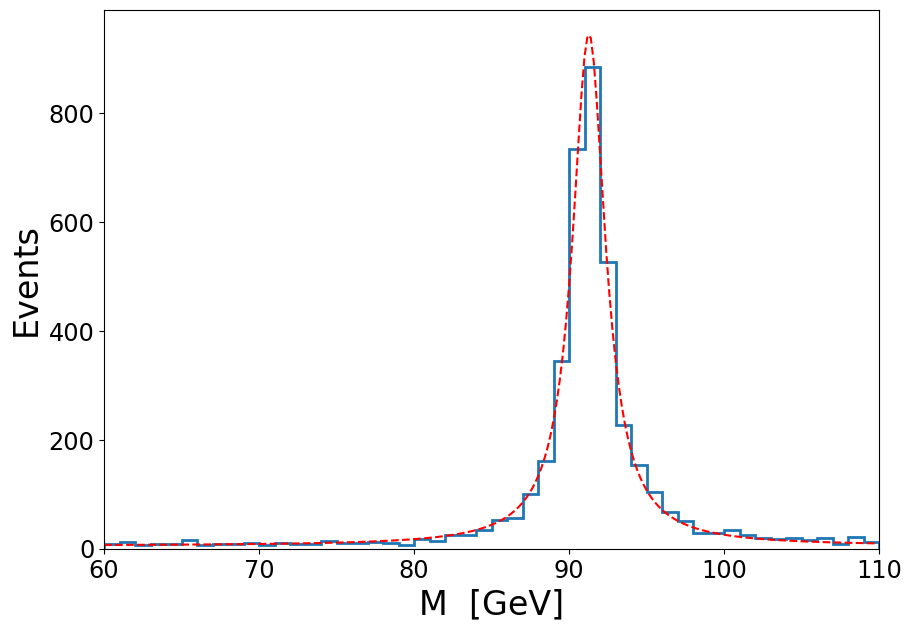

In [10]:
# Generated Z mass

mass_fit(Mgen)


 curve_fit results:

     par         sigma_p

    91.026  +/-  0.041 
     3.295  +/-  0.101 
   162.041  +/-  5.050 
     4.752  +/-  0.690 

 chi^2 =    44.594   chi^2/Ndf =  0.96944 


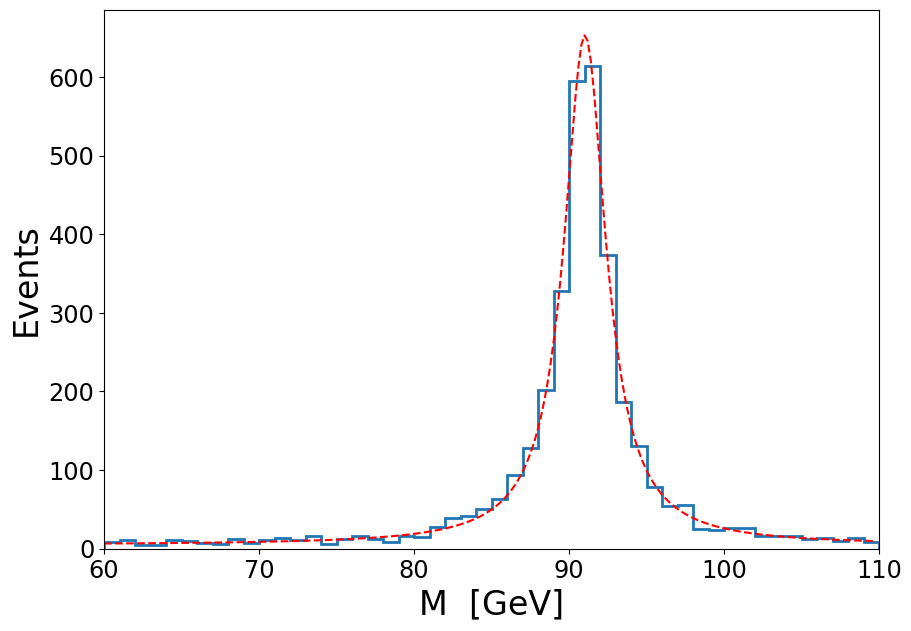

In [11]:
# Reconstructed Z mass

mass_fit(Mdet)


 curve_fit results:

     par         sigma_p

    -0.041  +/-  0.004 
     0.495  +/-  0.010 
   251.770  +/-  5.082 
    -4.304  +/-  0.918 

 chi^2 =   309.525   chi^2/Ndf =  6.72881 


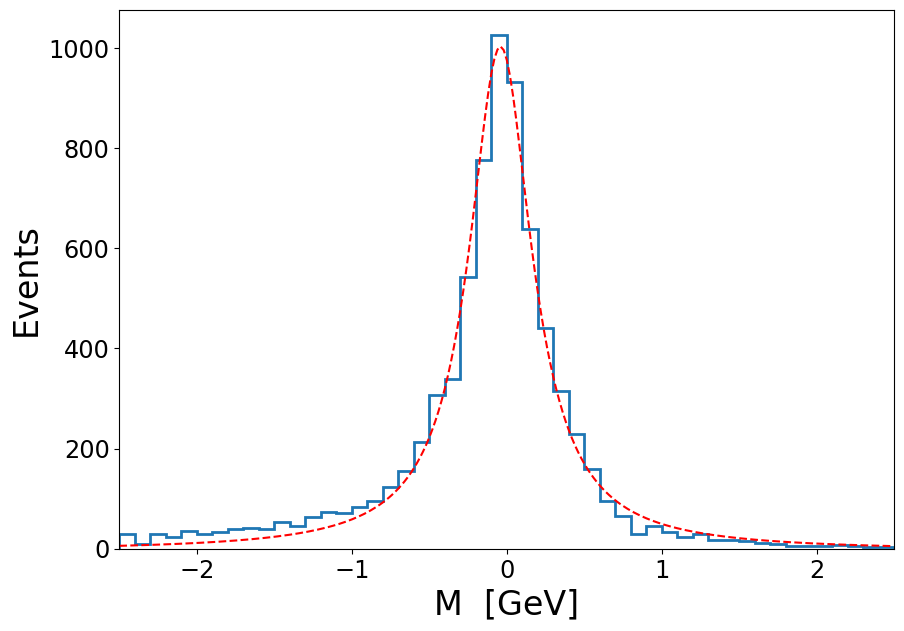

In [13]:
# Invariant mass measurement resolution 

mass_fit(Mdet-Msel,-2.5,2.5)